In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 6 - Solutions</h3>

<hr>

### Problem 1

In this assignment, you will work with a filtered version of the MNIST dataset to explore the ability of autoencoders to compress and reconstruct image data. You will build and evaluate a stacked and a convolutional autoencoder and compare their performance. Make sure to print any output you consider important to support your observations.

1) Load the Fashion-MNIST dataset from the **tensorflow.keras.datasets** module. Split the filtered dataset into a training set (5/7), a validation set (1/7), and a test set (1/7). Make sure the split uses stratified sampling to preserve class balance. Scale all subsets so that pixel values are in the range [0, 1], and reshape them to (28,28,1). <b>[5%]</b></br>

2) Build a stacked autoencoder consisting of an encoder with two fully-connected (Dense) hidden layers of 256 and 128 units, respectively, initialized with the **He Normal** distribution and activated by the **ReLU** activation function. Set the latent space (codings) size to 32, and build the decoder as a mirror copy of the encoder, with the appropriate activation function for the output layer. Flatten the input before feeding it to the encoder, and reshape the output to match the original image shape (28×28). Compile the model using an optimizer and a loss function of your choice. Print the model summary of this autoencoder. <b>[30%]</b></br></br>

3) Now, build a convolutional autoencoder consisting of an encoder with two 2D convolutional layers of 8 and 16 (3x3) kernels, respectively, with **ReLU** activation, each followed by a (2x2) Max Pooling layer. All layers should preserve the size of the input image. The decoder should contain two Conv2DTranspose layers with 16 and 8 (3x3) kernels, ReLU activation, strides of 2, and preserve the size of the input image. For the output layer, use a one (3x3) kernel Conv2D layer with a **sigmoid** activation function. All layers should preserve the size of the input image. Print the model summary for this autoencoder. <b>[35%]</b></br></br>

4) Train both autoencoders (from Q2 and Q3) for up to 50 epochs with a batch size of 32 images. Use early stopping with patience=5, and min_delta=0.005, monitoring the validation loss. Plot the training and validation loss for each model. <b>[20%]</b></br></br>

5) Apply each autoencoder to reconstruct the test set and calculate the Mean Absolute Reconstruction Error. Plot the first 15 images of the test set along with their reconstructed images for each model. Comment on your results. <b>[10%]</b>

#### Question 1

In [2]:
import random
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
RANDOM_STATE = 42

# Load Fashion MNIST
(x_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()


# Train (5/7) and validation (1/7)
X_train, X_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=1/6,
                                                  random_state=RANDOM_STATE, stratify=y_train_full)

X_train = X_train.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (50000, 28, 28, 1), y_train shape: (50000,)
X_val shape: (10000, 28, 28, 1), y_val shape: (10000,)
X_test shape: (10000, 28, 28, 1), y_test shape: (10000,)


In [3]:
# Normalize the data
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print(f"Train subset range: {X_train.min()} - {X_train.max()}")
print(f"Validation subset range: {X_val.min()} - {X_val.max()}")
print(f"Test subset range: {X_test.min()} - {X_test.max()}")

Train subset range: 0.0 - 1.0
Validation subset range: 0.0 - 1.0
Test subset range: 0.0 - 1.0


#### Question 2

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Set random seed for reproducibility
tf.random.set_seed(RANDOM_STATE)

codings = 32

# Define the autoencoder
inputs = Input(shape = (28, 28, 1))
x = Flatten()(inputs)                    

# Encoder
encoded = Dense(256, activation='relu', kernel_initializer='he_normal')(x)
encoded = Dense(128, activation='relu', kernel_initializer='he_normal')(encoded)
encoded = Dense(codings, activation='relu', kernel_initializer='he_normal', name="latent")(encoded)

# Decoder
decoded = Dense(128, activation='relu', kernel_initializer='he_normal')(encoded)
decoded = Dense(256, activation='relu', kernel_initializer='he_normal')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Reshape output to image format
outputs = Reshape((28, 28, 1))(decoded)

# Build model
fnn_ae = Model(inputs, outputs)
fnn_ae.compile(optimizer = Adam(), loss = 'binary_crossentropy')

# Print the model summary
print("Model summary:")
fnn_ae.summary()

Model summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 476,720 (1.82 MB)

 Trainable params: 476,720 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

#### Question 3

In [5]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose

inputs = Input(shape=(28, 28, 1))

# Encoder
encoded = Conv2D(8, (3, 3), activation="relu", kernel_initializer='he_normal', padding="same")(inputs)
encoded = MaxPooling2D((2, 2), padding="same")(encoded)
encoded = Conv2D(16, (3, 3), activation="relu", kernel_initializer='he_normal', padding="same")(encoded)
encoded = MaxPooling2D((2, 2), padding="same")(encoded)

# Decoder
decoded = Conv2DTranspose(16, (3, 3), strides=2, activation="relu", kernel_initializer='he_normal', padding="same")(encoded)
decoded = Conv2DTranspose(8, (3, 3), strides=2, activation="relu", kernel_initializer='he_normal', padding="same")(decoded)
decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(decoded)

# Autoencoder
conv_ae = Model(inputs, decoded)
conv_ae.compile(optimizer="adam", loss="binary_crossentropy")

# Print the model summary
print("Convolutional AE Summary:")
conv_ae.summary()

Convolutional AE Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 16)     │         2,320 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 8)      │         1,160 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

#### Question 4

In [6]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, min_delta=0.005)

# Fit the fnn_ae
history_fnn_ae = fnn_ae.fit(X_train, X_train,
                            validation_data=(X_val, X_val),
                            epochs=50,
                            batch_size=32,
                            callbacks=[early_stopping],
                            verbose=1)

print(f"Best epoch for the FFN-AE: {early_stopping.best_epoch + 1}")

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3430 - val_loss: 0.2886
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2864 - val_loss: 0.2816
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2806 - val_loss: 0.2782
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2777 - val_loss: 0.2763
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2759 - val_loss: 0.2753
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2747 - val_loss: 0.2747
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2741 - val_loss: 0.2743
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2733 - val_loss: 0.2735
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2728 - val_loss: 0.2734
Best epoch for the FFN-AE: 4


In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5,
                               restore_best_weights=True, min_delta=0.005)

# Fit the fnn_ae
history_conv_ae = conv_ae.fit(X_train, X_train,
                              validation_data=(X_val, X_val),
                              epochs=50,
                              batch_size=32,
                              callbacks=[early_stopping],
                              verbose=1)

print(f"Best epoch for the Conv-AE: {early_stopping.best_epoch + 1}")

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.3446 - val_loss: 0.2700
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2683 - val_loss: 0.2643
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2633 - val_loss: 0.2611
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2605 - val_loss: 0.2595
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2591 - val_loss: 0.2585
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.2582 - val_loss: 0.2579
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.2575 - val_loss: 0.2573
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.2571 - val_loss: 0.2570
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2567 - val_loss: 0.2567
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.2565 - val_loss: 0.2564
Best epoch for the Conv-AE: 5


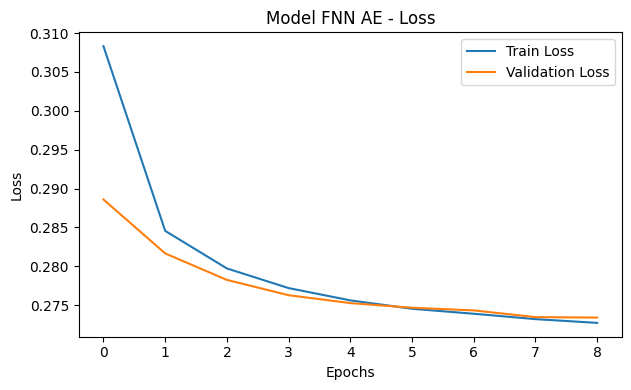

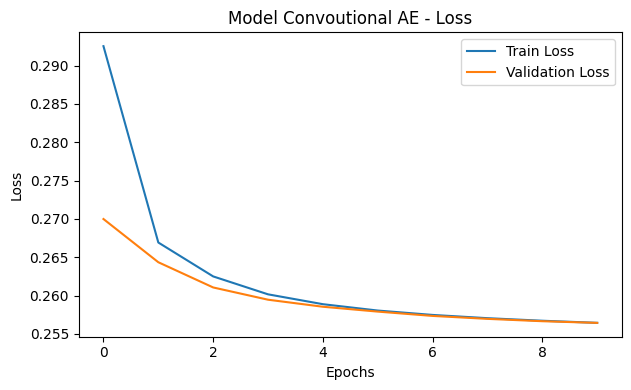

In [8]:
# Plotting the training history
import matplotlib.pyplot as plt

def plot_training_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
# Plot training history for both models
plot_training_history(history_fnn_ae,  "Model FNN AE")
plot_training_history(history_conv_ae, "Model Convoutional AE")

#### Question 5

In [9]:
# That function is the same with the notebook of the course
def plot_reconstructions(original, reconstructed, n_images=5):

    plt.figure(figsize=(n_images * 1.5, 3))
    
    for image_index in range(n_images):
        
        plt.subplot(2, n_images, 1 + image_index)
        plt.imshow(original[image_index], cmap="binary")
        plt.axis("off")

        plt.subplot(2, n_images, 1 + n_images + image_index)
        plt.imshow(reconstructed[image_index], cmap="binary")
        plt.axis("off")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step


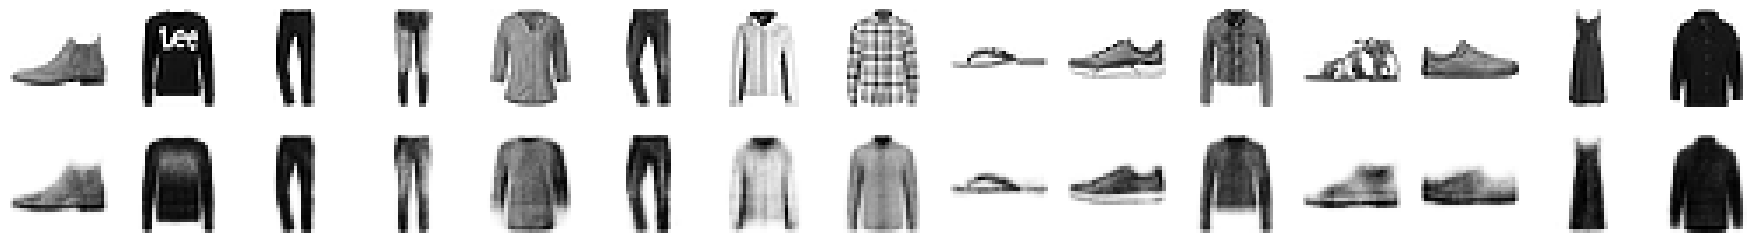

FNN mean reconstruction error: 0.05584246292710304


In [10]:
n_images=15
fnn_reconstructed = np.clip(fnn_ae.predict(X_test), 0, 1)

plot_reconstructions(X_test, fnn_reconstructed, n_images)
plt.show()

print(f"FNN mean reconstruction error: {np.mean(np.abs(X_test - fnn_reconstructed))}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


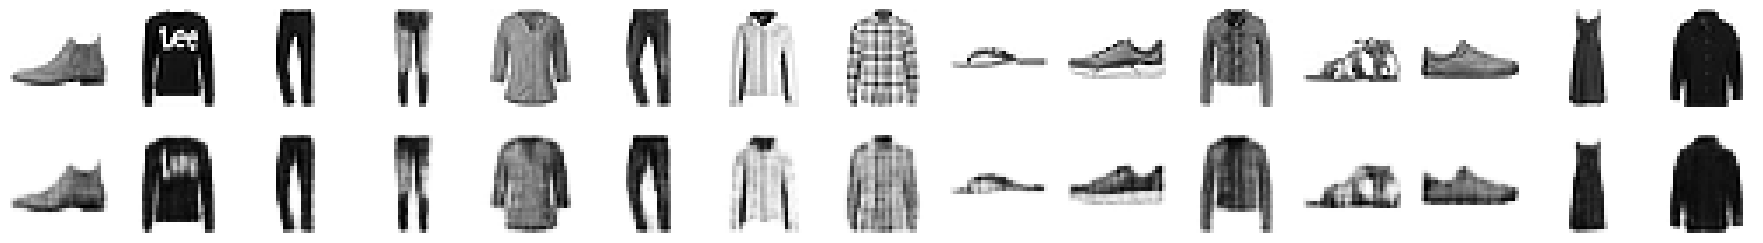

CNN mean reconstruction error: 0.03686871379613876


In [11]:
cnn_reconstructed = np.clip(conv_ae.predict(X_test), 0, 1)

plot_reconstructions(X_test, cnn_reconstructed, n_images)
plt.show()

print(f"CNN mean reconstruction error: {np.mean(np.abs(X_test - cnn_reconstructed))}")

#### Comment:
In both cases, the autoencoders are trained for 4–5 epochs before they begin to overfit the data. The convolutional autoencoder leverages its architectural structure and performs better than the fully connected one in terms of mean reconstruction error on the test set. The superiority of the convolutional autoencoder is also visually apparent in the reconstructed images.

### Problem 2

In this assignment, you will implement and train a Generative Adversarial Network (GAN) from scratch using the Fashion-MNIST dataset. Your GAN will learn to generate synthetic fashion item images that resemble real samples from selected categories. <i>Hint: Use tensorflow ~2.14 and follow the code of the book.</i>

1) Load the Fashion-MNIST dataset through tensorflow.keras.datasets, keep the data on the training set, select and retain only the T-shirt/top, Trousers, and Pullover classes, and scale the pixel values to the range [-1, 1]. <b>[5%]</b></br></br>

2) Create a generator that takes input random noise vectors of size 32. It has two hidden layers, each with 128 and 256 units, with an activation function ReLU and a He normal kernel initializer. It outputs a fully connected layer of a 784-dimensional vector with activation tanh, which is reshaped to a 28 by 28 pixels image. <b>[20%]</b></br></br>

3) Create a Discriminator that reads a 28 by 28 pixel image and classifies it as “real” or “fake”. The Discriminator consists of two hidden layers, each with 256 and 128 units, using ReLU activation and a He normal kernel initializer. A sigmoid function activates the output layer. <b>[20%]</b></br></br>

4) Connect the generator and discriminator to set up a GAN pipeline. Use the Binary Cross Entropy as the loss function and the RMSProp optimizer for both the discriminator and the GAN models. Create batches of 32 images by slicing the training set. Train the GAN for 10 epochs, alternating between updating the Discriminator and Generator models on each batch. After each epoch of training ends, visualize 32 generated images. <b>[35%]</b></br></br>

5) After training, feed the Generator with 32 random noise vectors and visualize the 32 generated images. Are you satisfied with the results? <b>[10%]</b></br></br>

6) What is the accuracy of the discriminator in predicting that the generated images of the previous question are fake? <b>[10%]</b>

In [12]:
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

#### Question 1

In [13]:
CLASSES = [0, 1, 2]  # T-shirt/top, Trouser, Pullover

(X_train, y_train), _ = tf.keras.datasets.fashion_mnist.load_data()

mask = np.isin(y_train, CLASSES)
X_train = X_train[mask].astype("float32") / 127.5 - 1  # Scale to [-1, 1]
y_train = y_train[mask]

#### Question 2

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

tf.random.set_seed(42)

codings_size = 32

generator = Sequential([
    Dense(128, activation = "relu", kernel_initializer = "he_normal"),
    Dense(256, activation = "relu", kernel_initializer = "he_normal"),
    Dense(28 * 28, activation = "tanh"),
    Reshape([28, 28])
])

#### Question 3

In [15]:
discriminator = Sequential([
    Flatten(),
    Dense(256, activation = "relu", kernel_initializer = "he_normal"),
    Dense(128, activation = "relu", kernel_initializer = "he_normal"),
    Dense(1, activation = "sigmoid")
])

#### Question 4

In [16]:
# Combine the generator and the discriminator model under the GAN
gan = Sequential([generator, discriminator])

# Compile the models
discriminator.compile(loss = "binary_crossentropy", optimizer = "rmsprop")
discriminator.trainable = False  # Fix the discriminators weight when training the generator

gan.compile(loss = "binary_crossentropy", optimizer = "rmsprop")

In [17]:
# visualize a given set of images
def plot_multiple_images(images, n_cols=None):
    n_cols = n_cols or len(images)
    n_rows = (len(images) - 1) // n_cols + 1
    if images.shape[-1] == 1:
        images = images.squeeze(axis=-1)
    plt.figure(figsize=(n_cols, n_rows))
    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image, cmap="binary")
        plt.axis("off")
    plt.show()

In [18]:
# Slice the dataset into batches
batch_size = 32

dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(1000)
dataset = dataset.batch(batch_size, drop_remainder=True).prefetch(1)

In [19]:
# built the training loop of both the GAN and the discriminator

def train_gan(gan, dataset, batch_size, codings_size, n_epochs):
    
    generator, discriminator = gan.layers

    for epoch in range(n_epochs):
        print(f"Epoch {epoch + 1}/{n_epochs}")

        # for each batch
        for X_batch in dataset:
            
            # phase 1 - training the discriminator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            generated_images = generator(noise)

            X_fake_and_real = tf.concat([generated_images, X_batch], axis=0)
            y1 = tf.constant([[0.]] * batch_size + [[1.]] * batch_size)
            discriminator.train_on_batch(x = X_fake_and_real, y = y1)

            # phase 2 - training the generator
            noise = tf.random.normal(shape=[batch_size, codings_size])
            y2 = tf.constant([[1.]] * batch_size)
            gan.train_on_batch(noise, y2)

        # visualize the generated images during training
        plot_multiple_images(generated_images.numpy(), 8)
        plt.show()

Epoch 1/10


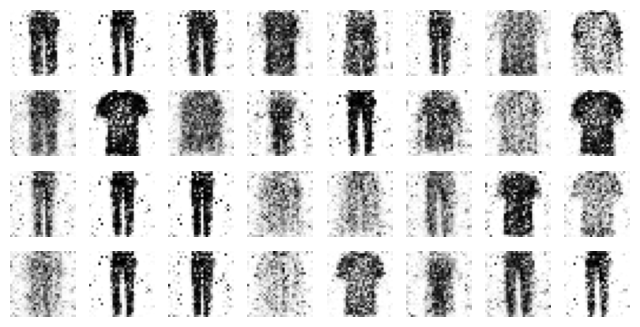

Epoch 2/10


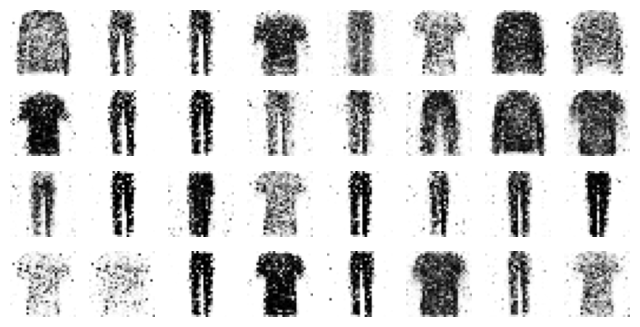

Epoch 3/10


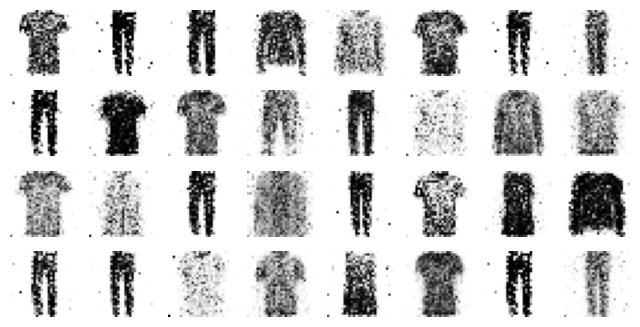

Epoch 4/10


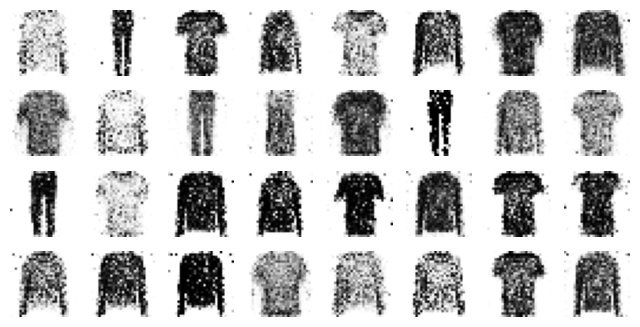

Epoch 5/10


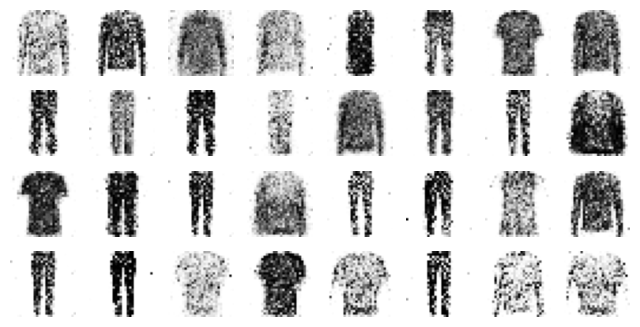

Epoch 6/10


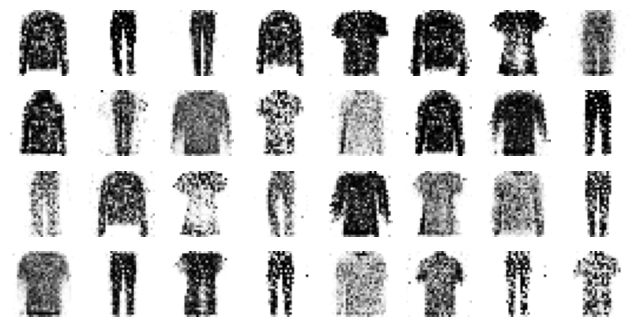

Epoch 7/10


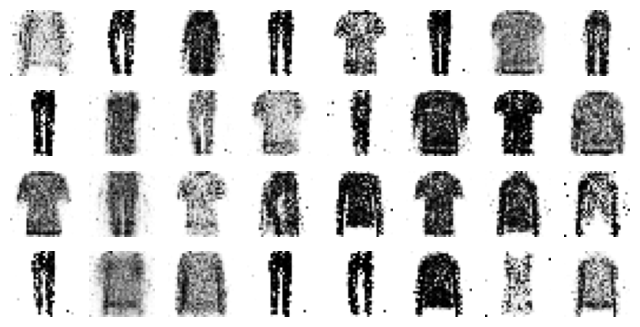

Epoch 8/10


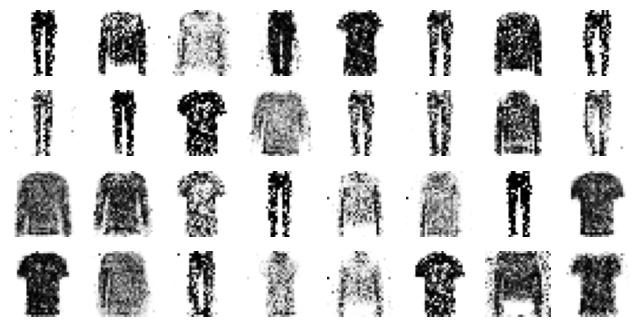

Epoch 9/10


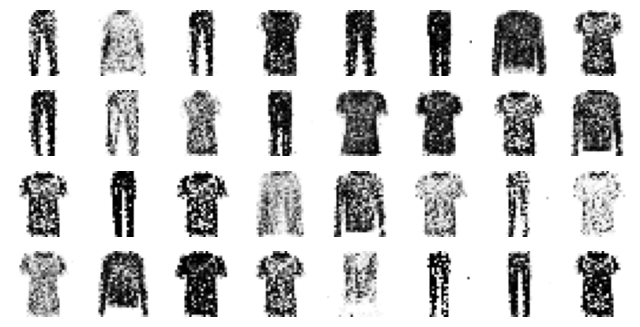

Epoch 10/10


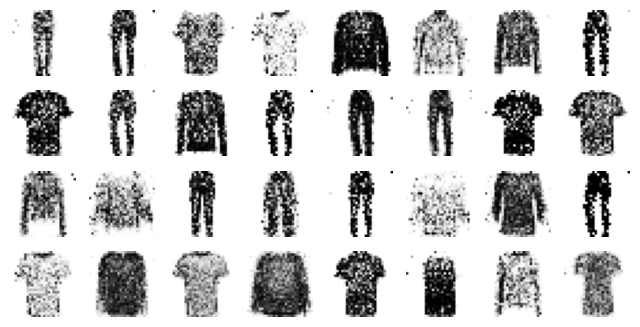

In [20]:
# train the models for 10 epochs
train_gan(gan, dataset, batch_size, codings_size, n_epochs=10)

#### Question 5

In [21]:
tf.random.set_seed(42)  # ensures reproducibility on CPU

codings = tf.random.normal(shape=[batch_size, codings_size])
generated_images = generator.predict(codings)

1/1 [==============================] - 0s 26ms/step


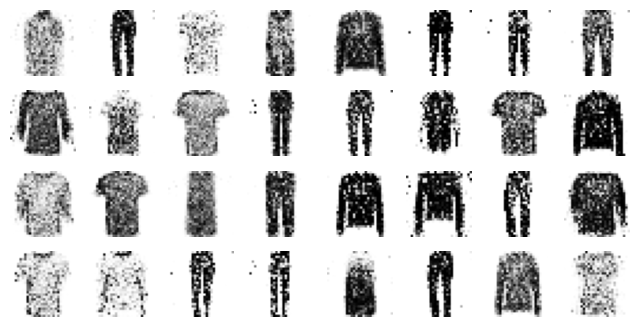

In [22]:
plot_multiple_images(generated_images, 8)

#### Question 6

In [23]:
predictions = discriminator.predict(generated_images)
fake = (predictions < 0.5).astype(int)  # less than 0.5 probability beeing a real image

1/1 [==============================] - 0s 22ms/step


In [24]:
print(f"Correctly classified as fake images: {fake.sum()/batch_size:%}")

Correctly classified as fake images: 71.875000%
